# Analysis of Repeated Antibiotics

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import os
import glob
import gzip
from matplotlib.ticker import PercentFormatter
%matplotlib inline

In [33]:
current_working_dir = os.getcwd()
print(current_working_dir)

c:\Users\m84300af\OneDrive - The University of Manchester\Documents\GitHub\amr-uom-brit


In [34]:
def makeFilePath(pathFromWorkspace, fileName):
    workingdir = "/workspace/" if (os.name != "nt") else ""
    filepath = workingdir+pathFromWorkspace+fileName

    return filepath

In [12]:
# # reads all csv.gz files in the path without considering their dates
# import glob

# path = 'output/measures'
# all_files = glob.glob(path + "/*.csv.gz")

# data2019 = []

# for filename in all_files:
#     df = pd.read_csv(filename, index_col=None, header=0)
#     data2019.append(df)

# data = pd.concat(data2019, axis=0, ignore_index=True)

# data#.head()

In [13]:
data2019_month = {}
data2020_month = {}
data2021_month = {}
data2019 = []
data2020 = []
data2021 = []
for  i in range(1, 13):
    # data of 2019
    input_file_path = makeFilePath("output/measures/", "input_2019-"+str(i).zfill(2)+"-01.csv.gz")
    data2019_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2019_month["%s" %i]['date'] = "2019-"+str(i).zfill(2)+"-01"
    data2019.append(data2019_month["%s" %i])
    # data of 2020
    input_file_path = makeFilePath("output/measures/", "input_2020-"+str(i).zfill(2)+"-01.csv.gz")
    data2020_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2020_month["%s" %i]['date'] = "2020-"+str(i).zfill(2)+"-01"
    data2020.append(data2020_month["%s" %i])
    # data of 2021
    input_file_path = makeFilePath("output/measures/", "input_2021-"+str(i).zfill(2)+"-01.csv.gz")
    data2021_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
    data2021.append(data2021_month["%s" %i])
    
data2019 = pd.concat(data2019_month, axis=0, ignore_index=True)
data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

data = data2019.append([data2020, data2021], ignore_index=True)

In [6]:
# data2019_month = {}
# data2020_month = {}
# data2021_month = {}
# data2019 = []
# data2020 = []
# data2021 = []
# for  i in range(1, 13):
#     # data of 2019
#     data2019_month["%s" %i] = pd.read_csv("output/measures/input_2019-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2019_month["%s" %i]['date'] = "2019-"+str(i).zfill(2)+"-01"
#     data2019.append(data2019_month["%s" %i])
#     # data of 2020
#     data2020_month["%s" %i] = pd.read_csv("output/measures/input_2020-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2020_month["%s" %i]['date'] = "2020-"+str(i).zfill(2)+"-01"
#     data2020.append(data2020_month["%s" %i])
#     # data of 2021
#     data2021_month["%s" %i] = pd.read_csv("output/measures/input_2021-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
#     data2021.append(data2021_month["%s" %i])
    
# data2019 = pd.concat(data2019_month, axis=0, ignore_index=True)
# data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
# data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

# data = data2019.append([data2020, data2021], ignore_index=True)

In [14]:
data#.head()

,bmi_date_measured,smoking_status_date,most_recent_unclear_smoking_cat_date,flu_vaccine_med,flu_vaccine_clinical,sgss_positive,covrx1_dat,covrx2_dat,died_date,uti_date_1,...,uti_ab_count_1,uti_ab_count_2,uti_ab_count_3,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,patient_id,date
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,5,0,4,4,0,6,0,2457,2019-01-01
1,2010-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-27,...,0,0,0,4,0,0,0,0,4943,2019-01-01
2,2014-08,NaN,2020-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,5,5,0,0,309,2019-01-01
3,2013-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,4,0,4,0,8272,2019-01-01
4,2012-02,2019-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,3,4,0,0,0,4,0,4625,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,2021-05,NaN,2019-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,4,4,0,5,5,4249,2021-12-01
35996,2016-10,NaN,2020-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,6359,2021-12-01
35997,NaN,2020-03,2021-03,2018-04,NaN,NaN,NaN,NaN,NaN,NaN,...,0,5,3,0,0,4,4,0,824,2021-12-01
35998,2011-05,2021-05,2019-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,0,0,5,0,0,5,0,1932,2021-12-01


In [112]:
# def read_csv_files(year):
#     data_month+str(year) = {}
#     data+str(year) = []
#     for i in range(1, 13):
#         # data of 2019
# #        data_month+str(year) = {}
#         if i <10:
#             data_month+str(year)["%s" %i] = pd.read_csv("output/measures/input_"+str(year)+"-0"+str(i)+"-01.csv.gz", compression='gzip')
#             data_month+str(year)["%s" %i]['date'] = str(year)+"-0"+str(i)+"-01"
#         else:
#             data_month+str(year)["%s" %i] = pd.read_csv("output/measures/input_"+str(year)+"-"+str(i)+"-01.csv.gz", compression='gzip')
#             data_month+str(year)["%s" %i]['date'] = str(year)+"-"+str(i)+"-01"
#             data+str(year).append(data_month+str(year)["%s" %i])
        
#     data+str(year) = pd.concat(data_month+str(year), axis=0, ignore_index=True)

# #data = data2019.append([data2020, data2021], ignore_index=True)

In [ ]:
# input_file_path = makeFilePath("output/measures/", "input_2021-"+str(i).zfill(2)+"-01.csv.gz")
# data2021_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
# data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
# data2021.append(data2021_month["%s" %i])

In [35]:
def read_csv_files(year):
    #datamonth[year] = {}
    # data2020_month = {}
    # data2021_month = {}
    #data[year] = []
    # data2020 = []
    # data2021 = []
    data_month ={}
    data[year]=[]
    for  i in range(1, 13):
        # data of 2019
        input_file_path = makeFilePath("output/measures/", "input_"+str(year)+"-"+str(i).zfill(2)+"-01.csv.gz")
        data_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
        data_month["%s" %i]['date'] = str(year)+"-"+str(i).zfill(2)+"-01"
        data[year].append(data_month["%s" %i])
    data[year] = pd.concat(data_month["%s" %i], axis=0, ignore_index=True)
    # data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
    # data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

#data = data2019.append([data2020, data2021], ignore_index=True)

In [36]:
read_csv_files(2019)

ValueError: Length of values (0) does not match length of index (36000)

In [24]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'sgss_positive', 'covrx1_dat', 'covrx2_dat',
       'died_date', 'uti_date_1', 'uti_ab_date_1', 'uti_date_2',
       'uti_ab_date_2', 'uti_date_3', 'uti_ab_date_3', 'uti_date_4',
       'uti_ab_date_4', 'lrti_date_1', 'lrti_ab_date_1', 'lrti_date_2',
       'lrti_ab_date_2', 'lrti_date_3', 'lrti_ab_date_3', 'lrti_date_4',
       'lrti_ab_date_4', 'age', 'age_cat', 'sex', 'practice', 'region', 'msoa',
       'imd', 'bmi', 'ethnicity', 'smoking_status', 'gp_count',
       'flu_vaccine_tpp', 'flu_vaccine', 'antibacterial_prescriptions',
       'antibacterial_brit', 'broad_spectrum_antibiotics_prescriptions',
       'primary_care_covid', 'admitted', 'uti_counts', 'lrti_counts',
       'urti_counts', 'sinusitis_counts', 'ot_externa_counts',
       'otmedia_counts', 'uti_pt', 'lrti_pt', 'urti_pt', 'sinusitis_pt',
       'ot_externa_pt', 'otmedia_

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 65 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   bmi_date_measured                         9612 non-null   object 
 1   smoking_status_date                       1200 non-null   object 
 2   most_recent_unclear_smoking_cat_date      1200 non-null   object 
 3   flu_vaccine_med                           1200 non-null   object 
 4   flu_vaccine_clinical                      1200 non-null   object 
 5   sgss_positive                             1200 non-null   object 
 6   covrx1_dat                                0 non-null      float64
 7   covrx2_dat                                0 non-null      float64
 8   died_date                                 1200 non-null   object 
 9   uti_date_1                                1200 non-null   object 
 10  uti_ab_date_1                     

In [157]:
data.describe()

,covrx1_dat,covrx2_dat,age,practice,imd,bmi,ethnicity,gp_count,flu_vaccine_tpp,flu_vaccine,...,otmedia_pt,uti_ab_count_1,uti_ab_count_2,uti_ab_count_3,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,patient_id
count,0.0,0.0,12000.000000,12000.000000,12000.000000,12000.000000,9000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,NaN,NaN,40.292833,24.548250,2.838917,22.424863,1.591778,3.319417,0.100000,0.100000,...,0.200000,0.901417,0.906250,0.901417,0.90525,0.901333,0.904083,0.898583,0.897917,4963.654583
std,NaN,NaN,23.655300,4.988311,1.530032,13.263640,1.266921,3.550578,0.300013,0.300013,...,0.400017,1.863551,1.869693,1.861985,1.86942,1.862495,1.865880,1.858965,1.855339,2887.106392
min,NaN,NaN,0.000000,4.000000,0.000000,-1.477351,1.000000,-5.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,21.000000,21.000000,2.000000,15.638096,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2456.000000
50%,NaN,NaN,40.000000,25.000000,3.000000,25.463437,1.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,4971.000000
75%,NaN,NaN,59.000000,28.000000,4.000000,31.901754,1.000000,6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,7444.000000
max,NaN,NaN,103.000000,48.000000,5.000000,61.101722,5.000000,19.000000,1.000000,1.000000,...,1.000000,8.000000,8.000000,8.000000,8.00000,8.000000,9.000000,9.000000,8.000000,9997.000000


In [31]:
data.uti_date_1.value_counts()

2020-04-19    3
2021-02-04    2
2021-08-08    2
2019-04-13    2
2021-05-22    2
             ..
2020-11-11    1
2021-07-05    1
2021-04-25    1
2020-03-20    1
2020-02-11    1
Name: uti_date_1, Length: 184, dtype: int64

In [32]:
data.loc[:, ['lrti_date_1', 'lrti_ab_count_1', 'lrti_date_2', 'lrti_ab_count_2', 'lrti_date_3', 'lrti_ab_count_3', 'lrti_date_4', 'lrti_ab_count_4']]

,lrti_date_1,lrti_ab_count_1,lrti_date_2,lrti_ab_count_2,lrti_date_3,lrti_ab_count_3,lrti_date_4,lrti_ab_count_4
0,NaN,0,2019-05-07,5,NaN,3,NaN,0
1,NaN,0,NaN,0,NaN,0,NaN,0
2,NaN,0,NaN,6,2020-03-27,0,NaN,5
3,NaN,0,NaN,0,2020-04-11,0,NaN,0
4,NaN,0,2021-03-15,3,NaN,5,NaN,0
...,...,...,...,...,...,...,...,...
1995,NaN,4,NaN,0,NaN,0,NaN,5
1996,NaN,0,NaN,0,NaN,5,NaN,0
1997,NaN,0,NaN,0,NaN,0,NaN,0
1998,NaN,0,NaN,0,NaN,0,NaN,5


In [33]:
#data.loc[:, ['urti_date_1', 'urti_ab_count_1', 'urti_date_2', 'urti_ab_count_2', 'urti_date_3', 'urti_ab_count_3', 'urti_date_4', 'urti_ab_count_4']]

In [34]:
data.loc[:, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4']]

,uti_date_1,uti_ab_count_1,uti_date_2,uti_ab_count_2,uti_date_3,uti_ab_count_3,uti_date_4,uti_ab_count_4
0,NaN,0,NaN,4,NaN,0,NaN,0
1,NaN,5,NaN,0,NaN,0,NaN,0
2,2020-08-20,6,NaN,0,NaN,4,NaN,0
3,NaN,0,NaN,0,NaN,0,2020-08-15,0
4,NaN,0,NaN,5,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
1995,NaN,0,NaN,0,NaN,0,2019-03-14,4
1996,NaN,4,NaN,0,NaN,4,NaN,0
1997,NaN,0,NaN,4,NaN,0,NaN,0
1998,NaN,0,NaN,5,2021-11-20,5,NaN,0


In [138]:
# data['repeated_ABs_UTI'] = np.nan

# col0 = data.columns.get_loc('repeated_ABs_UTI')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# for idx, x in enumerate(data['repeated_ABs_UTI']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             n=n+1
#     data.iat[idx, col0]=n

In [26]:
data['uti_date_1'] = pd.to_datetime(data['uti_date_1'], format='%Y-%m-%d', errors='ignore')
data['uti_date_2'] = pd.to_datetime(data['uti_date_2'], format='%Y-%m-%d', errors='ignore')
data['uti_date_3'] = pd.to_datetime(data['uti_date_3'], format='%Y-%m-%d', errors='ignore')
data['uti_date_4'] = pd.to_datetime(data['uti_date_4'], format='%Y-%m-%d', errors='ignore')

In [27]:
data['lrti_date_1'] = pd.to_datetime(data['lrti_date_1'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_2'] = pd.to_datetime(data['lrti_date_2'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_3'] = pd.to_datetime(data['lrti_date_3'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_4'] = pd.to_datetime(data['lrti_date_4'], format='%Y-%m-%d', errors='ignore')

In [ ]:
# data['uti_ab_date_1'] = pd.to_datetime(data['uti_ab_date_1'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_2'] = pd.to_datetime(data['uti_ab_date_2'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_3'] = pd.to_datetime(data['uti_ab_date_3'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_4'] = pd.to_datetime(data['uti_ab_date_4'], format='%Y-%m-%d', errors='ignore')

# data['lrti_ab_date_1'] = pd.to_datetime(data['lrti_ab_date_1'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_2'] = pd.to_datetime(data['lrti_ab_date_2'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_3'] = pd.to_datetime(data['lrti_ab_date_3'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_4'] = pd.to_datetime(data['lrti_ab_date_4'], format='%Y-%m-%d', errors='ignore')

In [141]:
# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
#                 n=n+1

#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
#                 n=n+1
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
#                 n=n+1
    
#     data.iat[idx, col0]=n

In [37]:
# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
#                 n=n+1
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
#                 n=n+1
    
#     data.iat[idx, col0]=n

In [28]:
# data['repeated_ABs'].value_counts()

## Cox model

In [32]:
import math
from lifelines import CoxPHFitter
from lifelines.calibration import survival_probability_calibration

In [29]:
data['repeated_ABs'] = np.nan
col0 = data.columns.get_loc('repeated_ABs')

col1 = data.columns.get_loc('uti_ab_count_1')
col2 = data.columns.get_loc('uti_ab_count_2')
col3 = data.columns.get_loc('uti_ab_count_3')
col4 = data.columns.get_loc('uti_ab_count_4')

col5 = data.columns.get_loc('uti_date_1')
col6 = data.columns.get_loc('uti_date_2')
col7 = data.columns.get_loc('uti_date_3')
col8 = data.columns.get_loc('uti_date_4')

col9 = data.columns.get_loc('lrti_ab_count_1')
col10 = data.columns.get_loc('lrti_ab_count_2')
col11 = data.columns.get_loc('lrti_ab_count_3')
col12 = data.columns.get_loc('lrti_ab_count_4')

col13 = data.columns.get_loc('lrti_date_1')
col14 = data.columns.get_loc('lrti_date_2')
col15 = data.columns.get_loc('lrti_date_3')
col16 = data.columns.get_loc('lrti_date_4')

for idx, x in enumerate(data['repeated_ABs']):
    n=0
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col1] > 0:
            if (data.iat[idx,col6]-data.iat[idx,col5]).days < 90:
                n=(data.iat[idx,col6]-data.iat[idx,col5]).days
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col2] > 0:
            if (data.iat[idx,col7]-data.iat[idx,col6]).days < 90:
                n=(data.iat[idx,col7]-data.iat[idx,col6]).days
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col3] > 0:
            if (data.iat[idx,col8]-data.iat[idx,col7]).days < 90:
                n=(data.iat[idx,col8]-data.iat[idx,col7]).days

    if data.iat[idx, col1] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col5]-data.iat[idx,col13]).days < 90:
                n=(data.iat[idx,col5]-data.iat[idx,col13]).days
    if data.iat[idx, col10] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col13]).days < 90:
                n=(data.iat[idx,col14]-data.iat[idx,col13]).days
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col14]).days < 90:
                n=(data.iat[idx,col15]-data.iat[idx,col14]).days
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col15]).days < 90:
                n=(data.iat[idx,col16]-data.iat[idx,col15]).days
    
    data.iat[idx, col0]=n

data['repeated_ABs'].value_counts()

 0.0      11982
 2.0          2
-848.0        1
-715.0        1
-6.0          1
-168.0        1
 35.0         1
-122.0        1
-814.0        1
-769.0        1
 58.0         1
-586.0        1
-332.0        1
-275.0        1
 45.0         1
-563.0        1
 48.0         1
 84.0         1
Name: repeated_ABs, dtype: int64

In [30]:
# replace any values smaller than -90
a = np.array(data['repeated_ABs'].values.tolist())
data['repeated_ABs'] = np.where(a < -90, np.nan, a).tolist()

# calculate absolute values for all rows in repeated_ABs column
data['repeated_ABs_time'] = data['repeated_ABs'].abs()

data['repeated_ABs_time'].value_counts()

0.0     11982
2.0         2
58.0        1
48.0        1
45.0        1
35.0        1
6.0         1
84.0        1
Name: repeated_ABs_time, dtype: int64

In [31]:
data['repeated_ABs_binary'] = data['repeated_ABs_time'].mask(data['repeated_ABs_time'] > 0, 1)

data['repeated_ABs_binary'].value_counts()

0.0    11982
1.0        8
Name: repeated_ABs_binary, dtype: int64

In [33]:
cph = CoxPHFitter()
Cox_data = data[['repeated_ABs_time', 'repeated_ABs_binary', 'age', 'sex', 'bmi', 'flu_vaccine']]

# printing number of missing values in each variable 
Cox_data.isnull().sum()

repeated_ABs_time      10
repeated_ABs_binary    10
age                     0
sex                     0
bmi                     0
flu_vaccine             0
dtype: int64

In [34]:
Cox_data = Cox_data.dropna(axis='rows')
Cox_data.isnull().sum()

repeated_ABs_time      0
repeated_ABs_binary    0
age                    0
sex                    0
bmi                    0
flu_vaccine            0
dtype: int64

In [35]:
print(Cox_data.shape)

(11990, 6)


<lifelines.CoxPHFitter: fitted with 11990 total observations, 11982 right-censored observations>
             duration col = 'repeated_ABs_time'
                event col = 'repeated_ABs_binary'
      baseline estimation = breslow
   number of observations = 11990
number of events observed = 8
   partial log-likelihood = -7.00
         time fit was run = 2021-12-02 17:31:40 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
age        -0.11       0.90       0.06            -0.23             0.00                 0.80                 1.00
bmi        -0.05       0.95       0.04            -0.13             0.03                 0.88                 1.03
sex[T.M]   -1.87       0.15       1.39            -4.61             0.86                 0.01                 2.36

              z    p   -log2(p)
covariate                      
age       -1.88 0.06       4.07
bmi       -1.25 0.21       2.25
sex[T.M]  -1.34 0.18       2.48
---
Concordance = 0.81
Partial AIC = 19.99
log-likelihood ratio test = 7.22 on 3 df
-log2(p) of ll-ratio test = 3.94

<AxesSubplot:xlabel='log(HR) (95% CI)'>

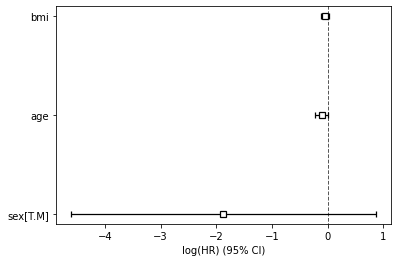

In [36]:
cph.fit(Cox_data, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="age + sex + bmi")
cph.print_summary()
cph.plot()

In [39]:
# cph.plot_partial_effects_on_outcome(covariates='sex', 
#                                     values=['F', 'M'], 
#                                     cmap='coolwarm')

In [40]:
# from lifelines.calibration import survival_probability_calibration

# cph.fit(Cox_data, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="age + sex")

# #plt.figure()

# survival_probability_calibration(cph, Cox_data, t0=90)
# #survival_probability_calibration(cph, dataCox, t0=70)

## Questions:
- I expect all dates to be within the one month period that the input data is supposedly generated/collected. How it is justified to have a date of 2020 (e.g. UTI diagnosis), while the data belongs to 2019? Is it becuase of having dummy data?
- Is our focus on repeated ABs for just one specific infection or any repeated ABs for any infection (LRTI and UTI)?